# TODO give this a better writeup
Currently copied from nn.ipynb, except a pickle file, Data_example_1D.pickle, from the salt repo (GUI) is used

Data from the example is used instead of the torch generated data.

TODO: there's a double vs float error later in the notebook, figure out typing stuff

# Stochastic Neural Network

Here we fit a stochastic neural network to two correlated outputs drawn from

$$ y_1(x) = \sin(\pi x) + \varepsilon_1 $$

and

$$
y_2(x) = \cos(\pi x) + \varepsilon_2
$$ 

with small Gaussian noise terms. The surrogate is a single-hidden-layer `tanh` network

$$ \hat{\mathbf{y}}(x) = W_2 \sigma(W_1 x + b_1) + b_2 $$

whose final-layer weights obey stochastic priors so we can sample functions.

In [1]:
# Import statements
import matplotlib.pyplot as plt
import torch
import pickle  # for loading from the pickle file

from pypolymix.parameter_groups import IIDGaussianGroup, DeterministicGroup
from pypolymix.surrogate_models import NeuralNetwork
from pypolymix import StochasticModel

In [2]:
# Set random seed
_ = torch.manual_seed(2048)

After the pickle file is parsed into an object, the object has

- one input: obj['data']['x'], which is a Numpy Array
- one output: obj['data']['U']['u'], which is a Numpy Array

In [3]:
with open("Data_example_1D.pickle", "rb") as f:
    obj = pickle.load(f)
obj

{'data': {'x': array([0.0000e+00, 1.0000e-02, 2.0000e-02, ..., 1.0097e+02, 1.0098e+02,
         1.0099e+02], shape=(10100,)),
  'U': {'u': array([0.00000000e+00, 1.00000000e-04, 4.00000000e-04, ...,
          1.01949409e+04, 1.01969604e+04, 1.01989801e+04], shape=(10100,))}}}

nn.txt generated synthetic data for X, y1, and y2. Here I use the pickle data for X and Y 

In [ ]:
# Generate synthetic data
NUM_SAMPLES = 10100 # length of pickle object properties
X = torch.from_numpy(obj['data']['x']).float().unsqueeze(1)
y1 = torch.from_numpy(obj['data']['U']['u']).float().unsqueeze(1)
y2 = torch.cos(torch.pi * X) + 0.05 * torch.randn(X.shape)
# create a 2-D tensor
# Y = torch.hstack((y1, y2))
# create a 1-D tensor, leave out the dummy y2
Y = y1
X

<function Tensor.type>

Two scatter plots (one per output) help visualize the phase shift between $\sin$ and $\cos$ so we know what structure the neural network must reproduce.

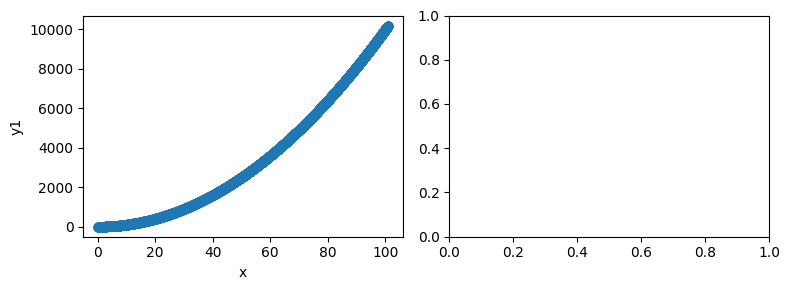

In [5]:
# Plot synthetic data
_, axes = plt.subplots(1, 2, figsize=(8, 3))
for j, (y, ax) in enumerate(zip(Y.T, axes.flatten())):
    ax.scatter(X, y)
    ax.set_xlabel("x")
    ax.set_ylabel(f"y{j + 1}")
plt.tight_layout()

We configure a width-16, depth-1 tanh network and print how many trainable parameters it contains so we have a sense of model capacity.

In [6]:
# Create a surrogate model
width = 16
depth = 1
surrogate_model = NeuralNetwork(num_inputs=1, num_outputs=2, width=width, depth=depth, activation=torch.nn.functional.tanh)
num_params = surrogate_model.num_params()
print(f"This model has {num_params} parameters")

This model has 66 parameters


All weights/biases up through the hidden layer are treated as deterministic, while the output-layer weights and biases follow i.i.d. Gaussian priors. This split lets us capture uncertainty primarily in the mapping from hidden features to the outputs, similar to a Bayesian neural network in the "Bayesian in the last layer" configuration.

In [7]:
# Create parameter groups
parameter_groups = [  # Input layer
    DeterministicGroup("input_layer_weights", width),
    DeterministicGroup("input_layer_biases", width),
]
for j in range(depth - 1):
    parameter_groups += [  # Hidden layers
        DeterministicGroup(f"layer{j + 1}_weights", width * width),
        DeterministicGroup(f"layer{j + 1}_biases", width),
    ]
parameter_groups += [  # Output layer
    IIDGaussianGroup("output_weights", 2 * width),
    IIDGaussianGroup("output_biases", 2),
]

The `StochasticModel` pairs the deterministic neural network with the grouped parameters so that sampling, log-prior penalties, and inference utilities become available.

In [8]:
# Create stochastic model
model = StochasticModel(
    surrogate_model=surrogate_model, parameter_groups=parameter_groups
)
print(f"Created stochastic model with {model.num_params()} parameters")

Created stochastic model with 66 parameters


We pick learning-rate and weight-decay values, set a small `weight_factor` for the distribution loss, introduce a learnable log-precision `log_tau`, and build the AdamW optimizer plus `OneCycleLR` scheduler.

In [9]:
# Training options
lr = 1e-3             # Learning rate
weight_decay = 1e-4   # Weight decay for AdamW
weight_factor = 1e-2  # Weight factor for distribution loss
num_epochs = 10000    # Number of epochs
num_samples = 100     # Number of parameter samples per epoch

# Learnable global precision
log_tau = torch.nn.Parameter(torch.tensor(0.0))  # τ = exp(log_tau)

# Optimizer: AdamW
optimizer = torch.optim.AdamW(
    list(model.parameters()) + [log_tau], lr=lr, weight_decay=weight_decay
)

# Loss
loss_fn = torch.nn.MSELoss(reduction="sum")

# Scheduler: OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=10 * lr,
    total_steps=num_epochs
)

Each epoch samples 100 parameter realizations, evaluates the network, computes the precision-scaled MSE on the predictive mean, adds the distribution regularizer, and performs backpropagation followed by the optimizer/scheduler updates.

In [10]:
# Train the stochastic model
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Evaluate parameters and model
    params = model.sample_parameters(num_samples=100)
    Y_hat = surrogate_model(X, params)

    # Losses
    data_loss = loss_fn(Y_hat, Y.unsqueeze(0).expand_as(Y_hat)) / num_samples
    data_loss *= torch.exp(log_tau)
    distribution_loss = model.distribution_loss()
    total_loss = data_loss + weight_factor * distribution_loss

    # Backprop + step
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # Logging
    if (epoch + 1) % 1000 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Epoch {epoch + 1:5d} | "
            f"learning rate = {current_lr:.6f} | "
            f"data loss = {data_loss.item():.4f} | "
            f"distribution loss = {distribution_loss.item():.4f} | "
            f"total loss = {total_loss.item():.4f}"
        )

Epoch  1000 | learning rate = 0.002801 | data loss = 164474322944.0000 | distribution loss = 86.0042 | total loss = 164474322944.0000
Epoch  2000 | learning rate = 0.007603 | data loss = 31774093312.0000 | distribution loss = 242.5706 | total loss = 31774093312.0000
Epoch  3000 | learning rate = 0.010000 | data loss = 9402452992.0000 | distribution loss = 421.7887 | total loss = 9402452992.0000
Epoch  4000 | learning rate = 0.009504 | data loss = 4180929024.0000 | distribution loss = 573.6910 | total loss = 4180929024.0000
Epoch  5000 | learning rate = 0.008116 | data loss = 2289025536.0000 | distribution loss = 702.0258 | total loss = 2289025536.0000
Epoch  6000 | learning rate = 0.006110 | data loss = 1432210688.0000 | distribution loss = 809.5947 | total loss = 1432210688.0000
Epoch  7000 | learning rate = 0.003885 | data loss = 1002949440.0000 | distribution loss = 896.0052 | total loss = 1002949440.0000
Epoch  8000 | learning rate = 0.001881 | data loss = 784741120.0000 | distribu

After training we switch to eval mode, create evenly spaced test points, and ask the stochastic model for 1000 posterior samples so we can estimate predictive uncertainty.

In [11]:
# Evaluate the model
model.eval()
with torch.no_grad():
    X_test = torch.linspace(X.min(), X.max(), 200).unsqueeze(1)
    Y_test = model(X_test, num_samples=1000)
Y_test[0]

tensor([[  0.6311,  -3.8516],
        [  3.0970,  -1.5607],
        [  5.3433,   0.5115],
        [  7.4382,   2.4273],
        [  9.4769,   4.2781],
        [ 11.6033,   6.2030],
        [ 14.0152,   8.3931],
        [ 16.9519,  11.0810],
        [ 20.6380,  14.4908],
        [ 25.1856,  18.7518],
        [ 30.5328,  23.8521],
        [ 36.4798,  29.6826],
        [ 42.7365,  36.0642],
        [ 48.9754,  42.7404],
        [ 55.0452,  49.5578],
        [ 61.2278,  56.7694],
        [ 68.1857,  64.9940],
        [ 76.6888,  74.8943],
        [ 87.0594,  86.6185],
        [ 97.8495,  98.4799],
        [106.2211, 107.5061],
        [111.0537, 112.6623],
        [113.3864, 115.1311],
        [114.4630, 116.2533],
        [114.9882, 116.7847],
        [115.2770, 117.0644],
        [115.4603, 117.2337],
        [115.5919, 117.3506],
        [115.6943, 117.4395],
        [115.7780, 117.5113],
        [115.8480, 117.5710],
        [115.9073, 117.6216],
        [115.9577, 117.6647],
        [1

For each output dimension we show the mean prediction and the central 90% credible interval obtained from the samples, plus the observed data for reference.

torch.Size([1000, 200, 2])
tensor([[-6.5643e+00, -4.2085e+00, -2.0443e+00, -5.8931e-02,  1.8476e+00,
          3.8431e+00,  6.1765e+00,  9.0541e+00,  1.2769e+01,  1.7358e+01,
          2.2593e+01,  2.8511e+01,  3.4764e+01,  4.1037e+01,  4.7199e+01,
          5.3708e+01,  6.1122e+01,  7.0098e+01,  8.1010e+01,  9.1906e+01,
          1.0013e+02,  1.0484e+02,  1.0706e+02,  1.0809e+02,  1.0857e+02,
          1.0883e+02,  1.0899e+02,  1.0911e+02,  1.0920e+02,  1.0927e+02,
          1.0933e+02,  1.0938e+02,  1.0943e+02,  1.0946e+02,  1.0950e+02,
          1.0952e+02,  1.0955e+02,  1.0957e+02,  1.0959e+02,  1.0960e+02,
          1.0962e+02,  1.0963e+02,  1.0964e+02,  1.0965e+02,  1.0965e+02,
          1.0966e+02,  1.0967e+02,  1.0967e+02,  1.0968e+02,  1.0968e+02,
          1.0968e+02,  1.0969e+02,  1.0969e+02,  1.0969e+02,  1.0969e+02,
          1.0969e+02,  1.0969e+02,  1.0970e+02,  1.0970e+02,  1.0970e+02,
          1.0970e+02,  1.0970e+02,  1.0970e+02,  1.0970e+02,  1.0970e+02,
          1

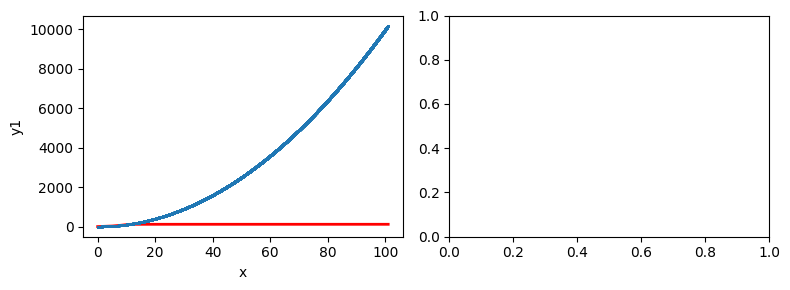

In [12]:
# Plot prediction
_, axes = plt.subplots(1, 2, figsize=(8, 3))
for j, (y, ax) in enumerate(zip(Y.T, axes.flatten())):
    x = X_test.squeeze(-1)
    q = torch.quantile(Y_test[:, :, j], torch.tensor([0.05, 0.5, 0.95]), axis=0)
    print(Y_test.shape)
    print(q)
    ax.fill_between(x, q[0], q[-1], color="red", alpha=0.5, linewidth=0)
    ax.plot(x, q[1], color="red", linewidth=2)
    ax.scatter(X, y, s=1, zorder=99) # changed dot size
    ax.set_xlabel("x")
    ax.set_ylabel(f"y{j + 1}")
plt.tight_layout()